# Week 3 — Exercise 2: Biological networks

**27200 Data-driven Bioengineering**

From a circuit of three genes to a network of a thousand. You will measure the properties Alon's
chapter 4 talks about on real yeast networks, and reproduce — in about ten lines — the result that
started the field of network motifs.

| Part | What | Data | Time |
|---|---|---|---|
| 1 | Degree, clustering, paths — by hand and by code | a 7-node toy graph | 5 min |
| 2 | Is a real protein network random? | yeast protein interactions (331 proteins) | 12 min |
| 3 | Network motifs — how often is a feed-forward loop *supposed* to appear? | yeast transcription network (Alon lab, 2002) | 12 min |
| 4 | Export for Cytoscape | → the Cytoscape exercise | 3 min |

Both datasets are fetched live from public URLs (a few hundred kB). **Every cell is complete and
commented**; read the plots and the questions.

> **Terms**
> **Graph / network** — a set of **nodes** (proteins, genes) joined by **edges** (interactions,
> regulation). *Undirected* if an edge has no direction (A binds B); *directed* if it does (A
> activates B).
> **Degree** (k) — the number of edges at a node. In a directed graph there is an **in-degree** and
> an **out-degree**. A **hub** is a node of unusually high degree.
> **Clustering coefficient** (C) — of the pairs of a node's neighbours, the fraction that are
> themselves connected. C = 1 means the node sits in a clique; C = 0 means its neighbours never
> touch each other.
> **Shortest path** — the fewest edges between two nodes. The **diameter** is the longest shortest
> path in the network. **Average path length** is the mean over all pairs.
> **Degree distribution** P(k) — the fraction of nodes with degree k. Its *shape* tells you what
> kind of network you have (Part 2).
> **`networkx`** — the Python library that does all of this.

In [ ]:
!pip install -q networkx

zsh:1: command not found: pip


In [ ]:
import io, requests
import numpy as np, pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

def fetch(url):
    '''Download a text file and return it as a string.'''
    r = requests.get(url, timeout=90, headers={"User-Agent": "27200-course"}); r.raise_for_status()
    return r.text
print("ready")

ready


---
## Part 1 — A graph small enough to check by hand

This is the network from the lecture slide. Before running the next cell, work out for yourself:
the degree of A, the clustering coefficient of B and of E, the shortest path C→F, and the diameter.
Then let the computer mark your work.

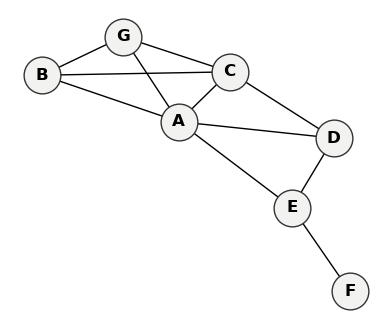

,A,B,C,D,E,F,G
degree,5.0,3.0,4.000,3.000,3.000,1.0,3.0
clustering,0.5,1.0,0.667,0.667,0.333,0.0,1.0


shortest path A-B : 1
shortest path B-E : 2   via ['B', 'A', 'E']
shortest path C-F : 3   via ['C', 'A', 'E', 'F']
diameter          : 3   (the longest of all shortest paths)


In [ ]:
toy = nx.Graph()
toy.add_edges_from([("A","B"), ("A","C"), ("A","D"), ("A","E"), ("A","G"),
                    ("B","C"), ("B","G"), ("C","G"), ("C","D"), ("D","E"), ("E","F")])

pos = nx.spring_layout(toy, seed=3)                                    # positions for drawing
fig, ax = plt.subplots(figsize=(4.8, 4))
nx.draw(toy, pos, ax=ax, with_labels=True, node_color="#f2f2f0", edgecolors="#333", node_size=700, font_weight="bold")
plt.show()

degree     = dict(toy.degree())                                        # edges per node
clustering = nx.clustering(toy)                                        # fraction of neighbour pairs that are connected
table = pd.DataFrame({"degree": degree, "clustering": clustering}).round(3).sort_index()
display(table.T)

print("shortest path A-B :", nx.shortest_path_length(toy, "A", "B"))
print("shortest path B-E :", nx.shortest_path_length(toy, "B", "E"), "  via", nx.shortest_path(toy, "B", "E"))
print("shortest path C-F :", nx.shortest_path_length(toy, "C", "F"), "  via", nx.shortest_path(toy, "C", "F"))
print("diameter          :", nx.diameter(toy), "  (the longest of all shortest paths)")

### Question 1.1 — reading the clustering column

**B and G have clustering coefficient 1, E has 1/3 and F has 0. Why?**

B and G both have clustering 1: every pair of their neighbours is connected — they sit in a tight
clique {A, B, C, G}. F has clustering 0 because with one neighbour there are no pairs to count. E has
1/3: of its three neighbour pairs (A–D, A–F, D–F) only A–D is an edge.

**Why clustering matters biologically:** a protein whose interaction partners also interact with
each other is probably part of a *complex*. One whose partners never meet is more likely a
*connector* between processes. Same degree, different role.

---
## Part 2 — Is a real protein network random?

A yeast protein-interaction network: 331 proteins, 362 interactions, mostly around the galactose
pathway. It ships with Cytoscape as the standard teaching dataset, and you will open it there in the
next exercise. First, measure it.

The question underneath everything here: **if you wired 331 proteins together with 362 edges at
random, would it look like this?** We will build that random network and check.

> **Terms**
> **Random graph** (Erdős–Rényi) — every possible edge is present with the same probability. Degrees
> are all roughly similar, clustered around the mean. The natural "null hypothesis" for a network.
> **Scale-free** — a network whose degree distribution follows a *power law*: most nodes have a few
> edges, a handful have very many. On a log-log plot, P(k) is a straight line with negative slope.
> Real biological networks are usually closer to this than to random.
> **Hierarchical** — clustering *decreases* with degree: hubs connect modules whose members are
> tightly clustered, but the hub's own neighbours barely interact with each other.
> **Small world** — short paths between any two nodes despite most nodes having few edges.

In [ ]:
BASE = "https://raw.githubusercontent.com/cytoscape/cytoscape-tutorials/gh-pages/protocols/data/"

# --- the network: SIF format is "source  interaction-type  target", one edge per line ---
sif = fetch(BASE + "galFiltered.sif")
ppi = nx.Graph()
for line in sif.strip().split("\n"):
    a, kind, b = line.split()
    ppi.add_edge(a, b, kind=kind)                     # kind is 'pp' (protein-protein) or 'pd' (protein-DNA)

# --- readable gene names, from the expression table that accompanies the network ---
expr = pd.read_csv(io.StringIO(fetch(BASE + "galExpData.csv")))
names = dict(zip(expr["GENE"], expr["COMMON"]))
nx.set_node_attributes(ppi, {n: names.get(n, n) for n in ppi}, "name")

n, m = ppi.number_of_nodes(), ppi.number_of_edges()
print(f"{n} proteins, {m} interactions  ({sum(1 for _,_,d in ppi.edges(data=True) if d['kind']=='pp')} protein-protein, "
      f"{sum(1 for _,_,d in ppi.edges(data=True) if d['kind']=='pd')} protein-DNA)")
print(f"mean degree            : {2*m/n:.2f}")
print(f"average clustering     : {nx.average_clustering(ppi):.3f}")
comps = sorted(nx.connected_components(ppi), key=len, reverse=True)
print(f"connected components   : {len(comps)}  (largest has {len(comps[0])} nodes)")
lcc = ppi.subgraph(comps[0])
print(f"diameter, largest comp : {nx.diameter(lcc)}")
print(f"average path length    : {nx.average_shortest_path_length(lcc):.2f}")

331 proteins, 361 interactions  (251 protein-protein, 110 protein-DNA)
mean degree            : 2.18
average clustering     : 0.072
connected components   : 26  (largest has 249 nodes)
diameter, largest comp : 27
average path length    : 9.05


A diameter of 27 on 249 nodes looks nothing like "six degrees of separation" — because this is not a
whole interactome. It is a thin slice filtered around one pathway, with a mean degree of just over 2,
so it is stringy rather than small-world. The full yeast interactome has ten times the edge density
and a diameter around 4–6. Keep that in mind whenever someone quotes a network statistic: **the
number describes the sample, not the organism.**

In [ ]:
# The five most connected proteins - the hubs
deg = pd.Series(dict(ppi.degree()), name="degree")
hubs = deg.sort_values(ascending=False).head(5)
print("hubs:")
for orf, k in hubs.items():
    print(f"   {names.get(orf, orf):<8} ({orf})  degree {k:>2}   clustering {nx.clustering(ppi, orf):.2f}")

# A random network with the SAME number of nodes and edges, for comparison
rnd = nx.gnm_random_graph(n, m, seed=27200)
print(f"\nrandom graph with the same n and m:")
print(f"   max degree {max(dict(rnd.degree()).values())}  (real: {deg.max()})")
print(f"   average clustering {nx.average_clustering(rnd):.3f}  (real: {nx.average_clustering(ppi):.3f})")

hubs:
   MCM1     (YMR043W)  degree 18   clustering 0.06
   RAP1     (YNL216W)  degree 17   clustering 0.00
   MIG1     (YGL035C)  degree 11   clustering 0.05
   GAL4     (YPL248C)  degree 10   clustering 0.18
   STE11    (YLR362W)  degree  9   clustering 0.03

random graph with the same n and m:
   max degree 7  (real: 18)
   average clustering 0.004  (real: 0.072)


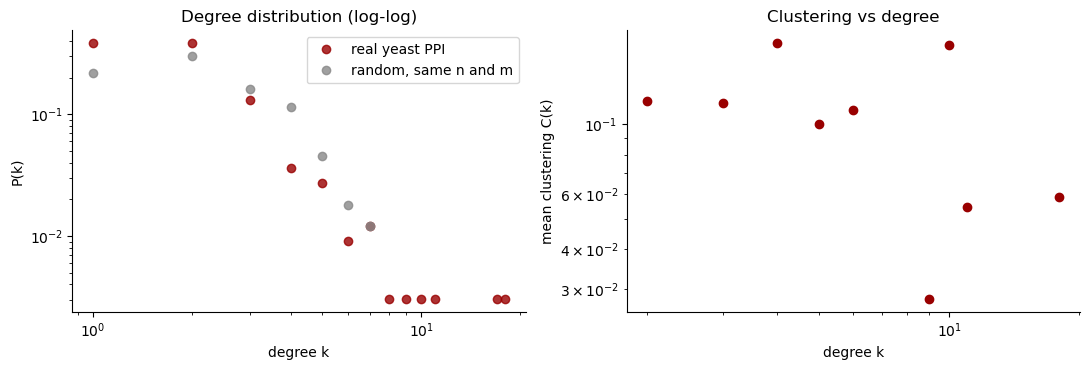

power-law fit: P(k) ~ k^(-2.14)     (a random graph has no straight line here at all)


In [ ]:
# Degree distribution: real vs random, on log-log axes
def degree_distribution(G):
    k = np.array([d for _, d in G.degree()])
    values, counts = np.unique(k[k > 0], return_counts=True)
    return values, counts / len(k)                     # P(k) = fraction of nodes with degree k

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for G, label, c in [(ppi, "real yeast PPI", "#990000"), (rnd, "random, same n and m", "#888")]:
    k, p = degree_distribution(G)
    axes[0].loglog(k, p, "o", ms=6, alpha=.8, label=label, color=c)
axes[0].set(xlabel="degree k", ylabel="P(k)", title="Degree distribution (log-log)"); axes[0].legend()

# Clustering as a function of degree: hierarchical networks slope downwards
ck = pd.DataFrame({"k": deg, "C": pd.Series(nx.clustering(ppi))})
ck = ck[ck.k > 1].groupby("k")["C"].mean()
axes[1].loglog(ck.index, ck.values, "o", color="#990000", ms=6)
axes[1].set(xlabel="degree k", ylabel="mean clustering C(k)", title="Clustering vs degree")
plt.tight_layout(); plt.show()

# Fit a straight line to the real degree distribution on log-log axes: the power-law exponent
k, p = degree_distribution(ppi)
slope, intercept = np.polyfit(np.log10(k), np.log10(p), 1)
print(f"power-law fit: P(k) ~ k^({slope:.2f})     (a random graph has no straight line here at all)")

### Question 2.1 — random or not?

**Does the real network look like its random twin? Where in the two plots can you tell?**

Three things separate the real network from its random twin, and all three are visible above:

1. **The degree distribution is a straight line on log-log axes** — a power law. Most proteins have
   one or two partners; a few have twenty. The random graph's degrees are bunched around the mean
   and its maximum degree is far lower. *Scale-free.*
2. **Clustering is more than ten times higher than random.** Proteins that share a partner tend to interact with
   each other — because they are in complexes.
3. **Clustering falls with degree.** The hubs' own neighbours are *not* clustered: hubs connect
   modules rather than sitting inside one. *Hierarchical.*

### Question 2.2 — why does this matter?

**So it is scale-free. Why should a biologist care?**

A scale-free network is **robust to random failure** (a random knockout almost always hits a
low-degree node) and **fragile to targeted attack** (knock out a hub and the network fragments).
That asymmetry is exactly what you see in yeast gene deletions: most are viable, deletions of hubs
are disproportionately lethal (Jeong et al., *Nature* 2001).

The power-law slope you fitted is the *b* parameter the old Cytoscape exercise asked about: for every
10× increase in degree, the fraction of nodes falls by roughly 10^|b|.

---
## Part 3 — Network motifs: is the feed-forward loop *over-represented*?

Chapter 4 of Alon, and the seminal for the field paper: Milo et al., *Science* 2002. The claim is
that certain small patterns — the feed-forward loop in particular — appear in real regulatory
networks **far more often than chance would predict**, and so were presumably selected for.

To test it you need a null model: random networks that keep everything boring about the real one (every node's in- and out-degree)
and randomise only the wiring. Then count FFLs in both.

We use the yeast transcription network from the Alon lab's own data collection — the same data as
the 2002 paper.

> **Terms**
> **Motif** — a small subgraph (here, three nodes) that occurs significantly more often in the real
> network than in randomised versions of it.
> **Degree-preserving randomisation** — shuffle the edges so every node keeps its exact number of
> incoming and outgoing edges, but who connects to whom is scrambled. Done by repeatedly picking two
> edges A→B and C→D and swapping their targets to A→D and C→B.
> **Z-score** — how many standard deviations the real count sits above the mean of the randomised
> counts. Z > 2 or so is considered significant; the 2002 paper reported Z ≈ 14 for the yeast FFL.

In [ ]:
import networkx as nx
import os

# Find your SIF file
for root, dirs, files in os.walk('/content/drive/MyDrive/DTU.Data bioengineering'):
    for file in files:
        if file.endswith('.sif'):
            print(os.path.join(root, file))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

sif = "/content/drive/MyDrive/DTU/Data bioengineering/yeast_trn.sif"

edges = []

with open(sif) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            source = parts[0]
            target = parts[2]
            edges.append((source, target))

trn = nx.DiGraph(edges)

# Remove self-loops
trn.remove_edges_from(nx.selfloop_edges(trn))

print("Nodes:", trn.number_of_nodes())
print("Edges:", trn.number_of_edges())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nodes: 688
Edges: 1079


feed-forward loops in the real network : 73
in 50 degree-preserving random networks: 14.3 ± 3.5
Z-score                                : 16.6


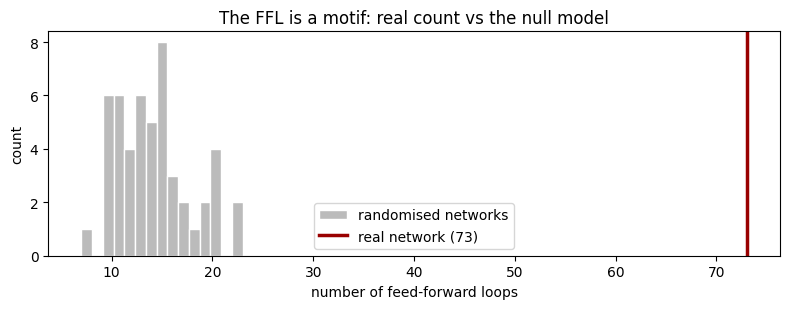

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def count_ffl(D):
    '''Feed-forward loops: X->Y, Y->Z and X->Z all present, three distinct nodes.'''
    n = 0
    for x in D:                                            # for every possible X...
        for y in D.successors(x):                          # ...every Y that X regulates...
            for z in D.successors(y):                      # ...every Z that Y regulates:
                if z != x and z != y and D.has_edge(x, z): # does X ALSO regulate Z directly?
                    n += 1
    return n

def randomise(D, rng, n_switch=None):
    '''Degree-preserving edge switching (Milo et al. 2002).'''
    R = D.copy(); E = list(R.edges())
    n_switch = n_switch or 10 * len(E)                     # enough switches to scramble everything
    done = tries = 0
    while done < n_switch and tries < 50 * n_switch:
        tries += 1
        i, j = rng.integers(len(E), size=2)
        (a, b), (c, d) = E[i], E[j]
        if len({a, b, c, d}) < 4 or R.has_edge(a, d) or R.has_edge(c, b):   # would create a self-loop or a duplicate
            continue
        R.remove_edges_from([(a, b), (c, d)]); R.add_edges_from([(a, d), (c, b)])
        E[i], E[j] = (a, d), (c, b); done += 1
    return R

real = count_ffl(trn)
rng = np.random.default_rng(27200)
random_counts = np.array([count_ffl(randomise(trn, rng)) for _ in range(50)])    # 50 randomised networks

z = (real - random_counts.mean()) / random_counts.std()
print(f"feed-forward loops in the real network : {real}")
print(f"in 50 degree-preserving random networks: {random_counts.mean():.1f} ± {random_counts.std():.1f}")
print(f"Z-score                                : {z:.1f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(random_counts, bins=15, color="#bbb", edgecolor="white", label="randomised networks")
ax.axvline(real, color="#990000", lw=2.5, label=f"real network ({real})")
ax.set(xlabel="number of feed-forward loops", ylabel="count", title="The FFL is a motif: real count vs the null model")
ax.legend(); plt.tight_layout(); plt.show()

### Back to Exercise 1

We saw why the FFL motif was over-represented in Exercise 1: it filters
out transient signals (coherent) or generates pulses (incoherent). Alon's argument is that the
statistics found the motif and the dynamics explained why it was selected. The counting and the
simulation are two halves of one argument.

---
## Part 4 — Export for Cytoscape

Cytoscape wants the network as a SIF file and any node attributes as a table. We write both, with
the degree and clustering you computed so you can colour nodes by them in Cytoscape.

In [ ]:
attrs = pd.DataFrame({
    "id":         list(ppi.nodes),
    "name":       [names.get(n, n) for n in ppi.nodes],
    "degree":     [ppi.degree(n) for n in ppi.nodes],
    "clustering": [round(nx.clustering(ppi, n), 3) for n in ppi.nodes],
})
attrs.to_csv("galFiltered_node_attributes.csv", index=False)
with open("galFiltered.sif", "w") as f:
    f.write(sif)
print("wrote galFiltered.sif and galFiltered_node_attributes.csv")
display(attrs.sort_values("degree", ascending=False).head())

# In Colab, push both files to your browser's download folder straight away.
# (Elsewhere - e.g. a local Jupyter - they are already in the working directory.)
try:
    from google.colab import files
    files.download("galFiltered.sif")
    files.download("galFiltered_node_attributes.csv")
    print("Downloads started - check your browser. If it blocked them, allow pop-ups for colab and rerun.")
except ImportError:
    print("Not running in Colab: the two files are in the notebook's working directory.")

wrote galFiltered.sif and galFiltered_node_attributes.csv


,id,name,degree,clustering
123,YMR043W,MCM1,18,0.059
37,YNL216W,RAP1,17,0.000
90,YGL035C,MIG1,11,0.055
93,YPL248C,GAL4,10,0.178
85,YLR362W,STE11,9,0.028


Not running in Colab: the two files are in the notebook's working directory.


Now open **`03_cytoscape_exercise.md`** and continue there.

---
## What to take away

1. **Degree, clustering and path length are the three numbers to compute first** on any network. They
   already tell you whether a node is in a complex or between complexes.
2. **Real biological networks are not random.** They are scale-free (a few hubs, many leaves), highly
   clustered (complexes), and hierarchical (hubs connect modules). The random graph is the null
   hypothesis you have to beat, and you beat it easily.
3. **A motif is a statistical claim, and it depends entirely on the null model.** Keep the degrees,
   scramble the wiring, count. The feed-forward loop survives that test with Z ≈ 14 — which is why
   Exercise 1 spent twenty minutes on what it does.
4. **The same file goes into Cytoscape** — which is where you look at a network rather than compute on
   it. Both matter; neither replaces the other.